# Data set Loading


In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import math, itertools, warnings
warnings.filterwarnings('ignore')
np.random.seed()

url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(url)
print(df.shape) # expected (1338, 7)
print(df.dtypes)
print(df.head())

(1338, 7)
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


# **Part#1**

# 1.1 The Normal Distribution - BMI

> ## sample mean (μ) and sample standard deviation (σ)

In [3]:
mean = round(df['bmi'].mean(),4)
std_dev = round(df['bmi'].std(),4)
print("Mean for BMI Column upto 4 Decimal Places is: ",mean)
print("Standard Deviation for BMI Column upto 4 Decimal Places is: ",std_dev)

Mean for BMI Column upto 4 Decimal Places is:  30.6634
Standard Deviation for BMI Column upto 4 Decimal Places is:  6.0982


> ## **Computing CDF**

In [4]:
under_weight_cdf = round(stats.norm.cdf(25,mean,std_dev),4)
temp_cdf = stats.norm.cdf(30,mean,std_dev)
over_weight_cdf = round(temp_cdf - under_weight_cdf,4)
obese_cdf = round(1 - temp_cdf,4)
print("Under Weight Preicted Probabilities are: ",under_weight_cdf)
print("Over Weight Preicted Probabilities are: ",over_weight_cdf)
print("Obese Preicted Probabilities are: ",obese_cdf)

Under Weight Preicted Probabilities are:  0.1765
Over Weight Preicted Probabilities are:  0.2802
Obese Preicted Probabilities are:  0.5433


> ## Actual Proportions

In [5]:
total = len(df)
under_weight_count = len(df[df['bmi'] < 25])
over_weight_count = len(df[(df['bmi'] >= 25) & (df['bmi'] < 30)])
obese_count = len(df[df['bmi'] >= 30])
under_weight_prop = round(under_weight_count / total,4)
over_weight_prop = round(over_weight_count / total,4)
obese_prop = round(obese_count / total,4)

print("Under Weight Proportion: ",under_weight_prop)
print("Over Weight Proportion: ",over_weight_prop)
print("Obese Proportion: ",obese_prop)

results_df = pd.DataFrame({
    'BMI Range': ['Underweight/Normal (<25)', 'Overweight (25-30)', 'Obese (>=30)'],
    'Actual Proportion': [under_weight_prop, over_weight_prop, obese_prop],
    'Predicted (Normal Model)': [under_weight_cdf, over_weight_cdf, obese_cdf]
})
print(results_df)

Under Weight Proportion:  0.1831
Over Weight Proportion:  0.2885
Obese Proportion:  0.5284
                  BMI Range  Actual Proportion  Predicted (Normal Model)
0  Underweight/Normal (<25)             0.1831                    0.1765
1        Overweight (25-30)             0.2885                    0.2802
2              Obese (>=30)             0.5284                    0.5433


> ## Histogram Plot

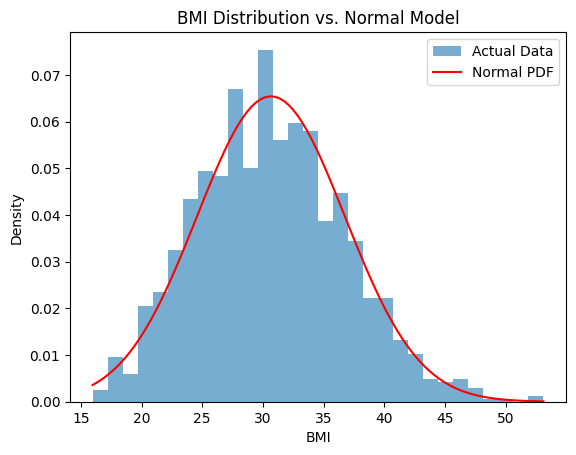

In [6]:
max_bmi = df['bmi'].max()
min_bmi = df['bmi'].min()
points = np.linspace(min_bmi,max_bmi,100)
pdf_value = stats.norm.pdf(points,mean,std_dev)
df['bmi'].plot.hist(bins=30,density=True,label = 'Actual Data',alpha = 0.6)
plt.plot(points,pdf_value,color='red',label = 'Normal PDF')
plt.title("BMI Distribution vs. Normal Model")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend()

> ## Distribution Analysis of BMI

- **Central Peak:** The actual data shows a slightly higher concentration of policyholders around the BMI range of **30** than the Normal model predicts. This indicates that the average risk group is more tightly clustered than expected.

- **Right-Side Skew:** There is a noticeable **right tail** in the histogram at higher BMI values. Several bars between **BMI 45 and 55** rise above the red PDF line, suggesting that the data is slightly **right-skewed**.

- **Overall Fit:** Despite these minor deviations, the **Normal distribution** remains a strong approximation for the overall BMI distribution of policyholders.

> ## 5th and 95th percentile of BMI

In [7]:
fifth_percentile = round(np.percentile(df['bmi'],5),4)
nintyfifth_percentile = round(np.percentile(df['bmi'],95),4)
fifth_ppf = round(stats.norm.ppf(0.05,mean,std_dev),4)
nintyfifth_ppf = round(stats.norm.ppf(0.95,mean,std_dev),4)
print("5th Percentile of Actual Data: ",fifth_percentile)
print("95th Percentile of Actual Data: ",nintyfifth_percentile)
print("5th Percentile of Modal Data: ",fifth_ppf)
print("95th Percentile of Modal Data: ",nintyfifth_ppf)

5th Percentile of Actual Data:  21.256
95th Percentile of Actual Data:  41.106
5th Percentile of Modal Data:  20.6328
95th Percentile of Modal Data:  40.694


> ## Percentile Comparison and Interpretation

As discussed earlier, the BMI distribution is **right-skewed**, which means the upper end of the data contains more extreme values than a perfectly Normal (model) distribution would predict.

- The **95th percentile** of the actual data is **higher** than the 95th percentile of the model data.
- This indicates that the real dataset contains more individuals with **very high BMI values** than expected under a simple Normal distribution.

Similarly, the **5th percentile** may also differ slightly, but the most noticeable deviation appears in the upper tail due to the right skew.

This confirms that the real-world BMI distribution includes more **“heavier” individuals** than a simple mathematical bell curve can fully account for.

# 1.2 The Binomial Distribution - Smoker Rate

> ## Empirical Probability

In [8]:
smoker_count = len(df[df['smoker'] == 'yes'])
non_smoker_count = len(df[df['smoker'] == 'no'])
smoker_prob = round(smoker_count / total,4)
non_smoker_prob = round(non_smoker_count / total,4)
print("Smoker Empirical Probability is: ",smoker_prob)
print("Non-Smoker Empirical Probability is: ",non_smoker_prob)

Smoker Empirical Probability is:  0.2048
Non-Smoker Empirical Probability is:  0.7952


> ## Probability of Exactly K Smokers 

In [9]:
def binomial_pmf(n, k, p):
    return math.comb(n, k) * (p**k) * ((1-p)**(n-k))
n = 50
k = [5,10,15,20]
p = smoker_prob
for i in range(4):
    result = binomial_pmf(n,k[i],p)
    print (f"Binomial Distribuition for k={k[i]} is=",round(result,4))


Binomial Distribuition for k=5 is= 0.0254
Binomial Distribuition for k=10 is= 0.1393
Binomial Distribuition for k=15 is= 0.0346
Binomial Distribuition for k=20 is= 0.0008


> ## **Compute P Using scipy.stats.binom.cdf**

In [10]:
k1 = 7
k2 = 20
Prob_fewer_than_8 = round(stats.binom.cdf(k1,n,smoker_prob),4) * 100
Prob_Greater_than_20 = round(1- stats.binom.cdf(k2,n,smoker_prob),4) * 100
print(f"Probability less than 8: {Prob_fewer_than_8}%",)
print(f"Probability Greater than 20: {Prob_Greater_than_20}%",)


Probability less than 8: 16.89%
Probability Greater than 20: 0.04%


> ## Risk Probability Interpretation

- **Low-Risk Probability:** There is a **16.89%** chance of having fewer than **8 smokers** in a random group of **50** policyholders. This suggests that nearly **1 in 6 groups** will have a relatively low smoking rate, which is favorable for the company’s overall risk profile.

- **High-Risk Probability:** The probability of having more than **20 smokers** in a group of **50** is extremely small, at only **0.04%**. This indicates that the likelihood of encountering an **over-saturated smoker group** is statistically negligible.

- **Conclusion:** Overall, the company’s risk remains well-centered around the expected average. Extreme cases with unusually high smoker concentration are highly unlikely to occur by chance, keeping the insurer’s exposure relatively stable and predictable.

> ## **Simulate 10,000 groups**

In [11]:
size = 10000
simulate_smokers = np.random.binomial(n,smoker_prob,size)
mean = smoker_prob * n
var = smoker_prob * n * non_smoker_prob
simulated_mean = np.mean(simulate_smokers)
simulated_var = np.var(simulate_smokers)
mean_error = (abs(mean - simulated_mean) / var ) * 100
var_error = (abs(var - simulated_var) / mean) * 100
print("Simulated Random Smokers are: ",simulate_smokers)
print("Theoretical Mean is: ",mean)
print("Theoretical Variance is: ",var)
print("Simulated Mean is: ",simulated_mean)
print("Simulated Variance is: ",simulated_var)
print(f"Mean Error is: {mean_error}%")
print(f"Variance Error is: {var_error}%")

Simulated Random Smokers are:  [12 10 10 ...  9 20 12]
Theoretical Mean is:  10.24
Theoretical Variance is:  8.142848
Simulated Mean is:  10.259
Simulated Variance is:  8.045719
Mean Error is: 0.23333359532193312%
Variance Error is: 0.9485253906250067%


> ## **Compute Separate Smoker Rates for Males and Females**

In [12]:
male_df = df[df['sex'] == "male"]
female_df = df[df['sex'] == "female"]
male_total = len(male_df)
female_total = len(female_df)
male_smokers_count = len(male_df[male_df['smoker'] == 'yes'])
female_smokers_count = len(female_df[female_df['smoker'] == 'yes'])
male_smokers_prob = male_smokers_count / male_total
female_smokers_prob = female_smokers_count / female_total
expected_male_smokers = round(n * male_smokers_prob,4)
expected_female_smokers = round(n * female_smokers_prob,4)
prob_female_zero_smokers = stats.binom.pmf(0,n,female_smokers_prob)
prob_male_zero_smokers = stats.binom.pmf(0,n,male_smokers_prob)
final_results = {
    'Sex': ['Male','Female'],
    'Expected Smokers': [expected_male_smokers,expected_female_smokers],
    'P(Zero Smokers)':[round(prob_male_zero_smokers,4),round(prob_female_zero_smokers,4)]
    
}
fdf = pd.DataFrame(final_results)
print("Expected Male Smokers are:",expected_male_smokers)
print("Expected Female Smokers are:" ,expected_female_smokers)
print("Probability of Male Zero Smokers: ",prob_male_zero_smokers)
print("Probability of Female Zero Smokers: ",prob_female_zero_smokers)
print(fdf)

Expected Male Smokers are: 11.7604
Expected Female Smokers are: 8.6858
Probability of Male Zero Smokers:  1.5038078848587274e-06
Probability of Female Zero Smokers:  7.185662988293868e-05
      Sex  Expected Smokers  P(Zero Smokers)
0    Male           11.7604           0.0000
1  Female            8.6858           0.0001



## **1.3  The Poisson Distribution - Number of Dependants**

> ## **Compute the mean (λ) and variance**

In [13]:
child_mean = round(df['children'].mean(),4)
child_var = round(df['children'].var(),4)
dispersion_ratio = round(child_mean / child_var,4)
print("Mean:",child_mean)
print("Variance:",child_var)
print("Dispersion Ratio: ",dispersion_ratio)

Mean: 1.0949
Variance: 1.4532
Dispersion Ratio:  0.7534


## Dispersion Ratio Interpretation

The calculated **dispersion ratio** is **0.7534**, which is reasonably close to **1**. In count-data analysis, a dispersion ratio near **1** indicates that the data follows the assumptions of a **Poisson distribution** fairly well.

This suggests that the Poisson model provides a **good fit** for the smoker count data, as the observed variance is close to the mean. Although the ratio is slightly below 1 (indicating mild under-dispersion), it is still close enough to support the conclusion that the **Poisson distribution is an appropriate model** for this dataset.

> ## Using Poisson PMF Formula

In [14]:
def poisson_pmf(k,lam):
    numerator = (lam ** k) * math.exp(-lam)
    denomerator = math.factorial(k)
    return numerator / denomerator
lam = child_mean
for x in range(5):
    print(f"Poisson PMF for X={x} using manual calculations is:",round(poisson_pmf(x,lam),4))
for x in range(5):
    print(f"Poisson PMF for X={x} using scipy.stats calculations is:",round(stats.poisson.pmf(x,lam),4))

Poisson PMF for X=0 using manual calculations is: 0.3346
Poisson PMF for X=1 using manual calculations is: 0.3663
Poisson PMF for X=2 using manual calculations is: 0.2005
Poisson PMF for X=3 using manual calculations is: 0.0732
Poisson PMF for X=4 using manual calculations is: 0.02
Poisson PMF for X=0 using scipy.stats calculations is: 0.3346
Poisson PMF for X=1 using scipy.stats calculations is: 0.3663
Poisson PMF for X=2 using scipy.stats calculations is: 0.2005
Poisson PMF for X=3 using scipy.stats calculations is: 0.0732
Poisson PMF for X=4 using scipy.stats calculations is: 0.02


> ## **Compare the Poisson-predicted probabilities**

In [15]:
total = len(df['children'])
count = df['children'].value_counts()
count_0 = count[0]
count_1 = count[1]
count_2 = count[2]
count_3 = count[3]
count_4 = count[4]
count_0_proportion = round(count_0 / total,4) 
count_1_proportion = round(count_1 / total,4) 
count_2_proportion = round(count_2 / total,4) 
count_3_proportion = round(count_3 / total,4) 
count_4_proportion = round(count_4 / total,4)
data = []
proportions = [count_0_proportion,count_1_proportion,count_2_proportion,count_3_proportion,count_4_proportion]
for x in range(5):
    pmf_val = round(stats.poisson.pmf(x, lam), 4) 
    data.append(pmf_val)
data_frame = {
    "Children" : [0,1,2,3,4],
    "Actual-Proportions %": proportions,
    "Poison-PMF %" : data,
    "Difference":  np.array(proportions) - np.array(data)
}
fdf = pd.DataFrame(data_frame)
print(fdf)

   Children  Actual-Proportions %  Poison-PMF %  Difference
0         0                0.4290        0.3346      0.0944
1         1                0.2422        0.3663     -0.1241
2         2                0.1794        0.2005     -0.0211
3         3                0.1173        0.0732      0.0441
4         4                0.0187        0.0200     -0.0013


> ## Poisson Model Fit Analysis

The largest difference between the **Poisson model** and the **actual data** occurs at **\(k = 1\)**, with a gap of **\(-0.1241\)**.  
This negative value indicates that the Poisson model **overestimates** the proportion of policyholders with exactly **one child** by more than **12%**.

In contrast, the model **underestimates** the proportion of policyholders with **no children** (**\(k = 0\)**).

These differences show that while the Poisson distribution captures the general pattern of family size counts, it does not perfectly represent the observed distribution. In particular, the mismatch at lower child counts suggests that the Poisson model is only an **approximate fit** for this dataset’s family-size behavior.

> ## **Compute P(children ≥ 3)**

In [16]:
p_poisson_model = round(1 - stats.poisson.cdf(2,lam),4)
count_greater_3 = len(df[df['children'] >= 3])
p_poisson_actual = round(count_greater_3 / total,4)
percentage_error = round(((p_poisson_actual-p_poisson_model) / p_poisson_actual) * 100,4)
print("Probability using Poisson Model: ",p_poisson_model)
print("Probability Using Actual Value: ",p_poisson_actual)
print(f"Percentage Error is:{percentage_error}%")

Probability using Poisson Model:  0.0986
Probability Using Actual Value:  0.1495
Percentage Error is:34.0468%


## Family Pricing Risk

The dataset shows that **200 policyholders** (**14.95%**) have **3 or more dependants**, indicating a segment that may require a dedicated **family pricing review**.

The **Poisson model** predicted only **9.86%** for this group, significantly **underestimating** the true proportion of high-dependant policyholders. This resulted in a substantial **34.05% percentage error**.

Because of this underestimation, the pricing team should place greater reliance on **actual historical data** rather than the Poisson model when evaluating high-dependant policies. Doing so will reduce the risk of underpricing and help better account for the true financial impact of larger-family policyholders.

# **Part#2**


# **2.1  Do Smokers Cost the Company Significantly More?**

In [17]:
smoker = df[df['smoker'] == 'yes']
non_smoker = df[df['smoker']=='no']
smoker_group = smoker['charges']
non_smoker_group = non_smoker['charges']
smoker_group_n = smoker_group.count()
non_smoker_group_n = non_smoker_group.count()
smoker_group_mean = round(smoker_group.mean(),4)
non_smoker_group_mean = round(non_smoker_group.mean(),4)
smoker_group_std_dev = round(smoker_group.std(),4)
non_smoker_group_std_dev = round(non_smoker_group.std(),4)
smoker_group_median = round(smoker_group.median(),4)
non_smoker_group_median = round(non_smoker_group.median(),4)
data = {
    "Smoker" : [smoker_group_n,smoker_group_mean,smoker_group_std_dev,smoker_group_median],
    "Non-Smoker" : [non_smoker_group_n,non_smoker_group_mean,non_smoker_group_std_dev,non_smoker_group_median]
}
summary = pd.DataFrame(data,index=['n','Mean','Standard Deviation','Median'])
print(summary)

                        Smoker  Non-Smoker
n                     274.0000   1064.0000
Mean                32050.2318   8434.2683
Standard Deviation  11541.5472   5993.7818
Median              34456.3485   7345.4053


## Cost Variability Summary

Non-smokers have a much lower standard deviation, meaning their insurance charges are more consistent and predictable.  
Smokers show much higher variability in charges, making them a less stable and more financially risky group.  
Since smoker charges are nearly four times higher on average, the hypothesis test is expected to show a statistically significant difference.

Text(0, 0.5, 'Charges')

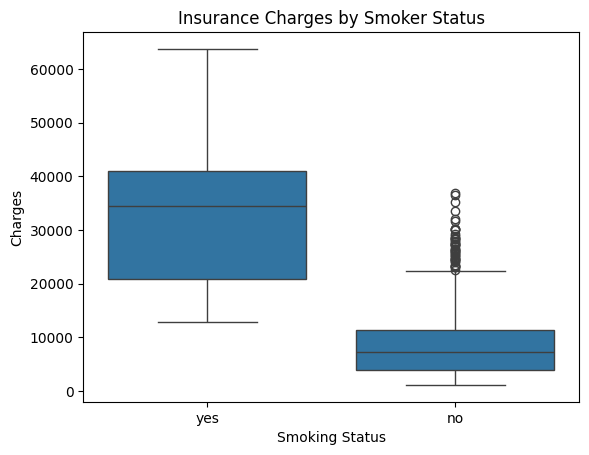

In [18]:
sns.boxplot(x='smoker',y='charges',data=df)
plt.title("Insurance Charges by Smoker Status")
plt.xlabel('Smoking Status')
plt.ylabel('Charges')

> ## Analysis of the Plot

  * The smoker box is much taller than the non-smoker box, showing that smoker charges have far greater spread and variance.  
  *  Several outliers appear above the non-smoker group, indicating that some non-smokers still have unusually high charges.  
  *  The smoker median is around 35,000 while the non-smoker median is below 10,000, with no meaningful overlap between the two groups.

> ## Levene’s Test 

In [19]:
stat,p_value  = stats.levene(smoker_group,non_smoker_group)
print("Statisitc value: ",round(stat,4))
print("P-Value: ",p_value)

Statisitc value:  332.6135
P-Value:  1.5593284881803726e-66


> ## Levene’s Test Interpretation

The p-value from **Levene’s Test** is well below **0.05**, so the null hypothesis of equal variance is rejected.  
This confirms that the spread of insurance charges for smokers is significantly different from that of non-smokers, supporting the box plot observation.  
Because the variances are unequal, **Welch’s T-test** (**equal_var = False**) should be used to compare the group means.

> ## scipy.stats.ttest_ind 

In [20]:
stat,p_value = stats.ttest_ind(smoker_group,non_smoker_group,equal_var=False)
print("Statisitc value: ",round(stat,4))
print("P-Value: ",p_value)

Statisitc value:  32.7519
P-Value:  5.88946444671698e-103


## Welch’s T-Test Interpretation

The p-value from **Welch’s T-Test** is well below **0.05**, so the null hypothesis of equal means is rejected.  
This confirms that the average insurance charges for smokers are significantly higher than those for non-smokers.  
The difference is both statistically significant and financially substantial, with smokers paying far more on average.

> ## **Confidence Interval**

In [32]:
mean_diff = smoker_group_mean - non_smoker_group_mean
smoker_group_var = smoker_group.var()
non_smoker_group_var = non_smoker_group.var()
standard_error = np.sqrt(smoker_group_var/smoker_group_n + non_smoker_group_var/smoker_group_n)
error_margin = 1.96 * standard_error
lower_bound = mean_diff - error_margin
upper_bound = mean_diff + error_margin
print("Standard Error is:",round(standard_error,4))
print("Error Margin:",round(error_margin,4))
print("Lower Bound: ",round(lower_bound,4))
print("Upper Bound: ",round(upper_bound,4))

Standard Error is: 785.6671
Error Margin: 1539.9075
Lower Bound:  22076.056
Upper Bound:  25155.871


>  ## **Confidence Interval Interpretation**
The company can expect smokers to cost between **$22,076.06** and **$25,155.87** more per year than non-smokers, with **95% confidence**.

> ## **Compute Cohen's d.**

In [37]:
pooled_varience = (((smoker_group_n - 1) * smoker_group_var) + ((non_smoker_group_n - 1) * non_smoker_group_var)) / (smoker_group_n + non_smoker_group_n - 2) 
pooled_std_dev = np.sqrt(pooled_varience)
cohen_d = mean_diff / pooled_std_dev
print("Cohen's d:",round(cohen_d,4))

Cohen's d: 3.1613


## Effect Size Interpretation

This is an **extremely large** effect size, showing that the difference is highly practically significant.  
The two groups are financially very distinct, with smokers creating a much greater cost impact on the company.  
A separate pricing tier is clearly justified, as charging both groups the same premium would ignore a major and statistically robust cost difference.

In [39]:
stat, p_value = stats.mannwhitneyu(smoker_group, non_smoker_group, alternative='two-sided')
print("U-Statisitc value: ",round(stat,4))
print("P-Value: ",p_value)

U-Statisitc value:  284133.0
P-Value:  5.270233444503571e-130


## Mann-Whitney U Test Interpretation

The Mann-Whitney U test returned a statistic of **284,133** and a p-value of **\(5.27 \times 10^{-130}\)**, confirming a highly significant difference between the two groups.  
This strongly supports the T-test result and confirms that smokers consistently have higher insurance charges than non-smokers across the dataset.